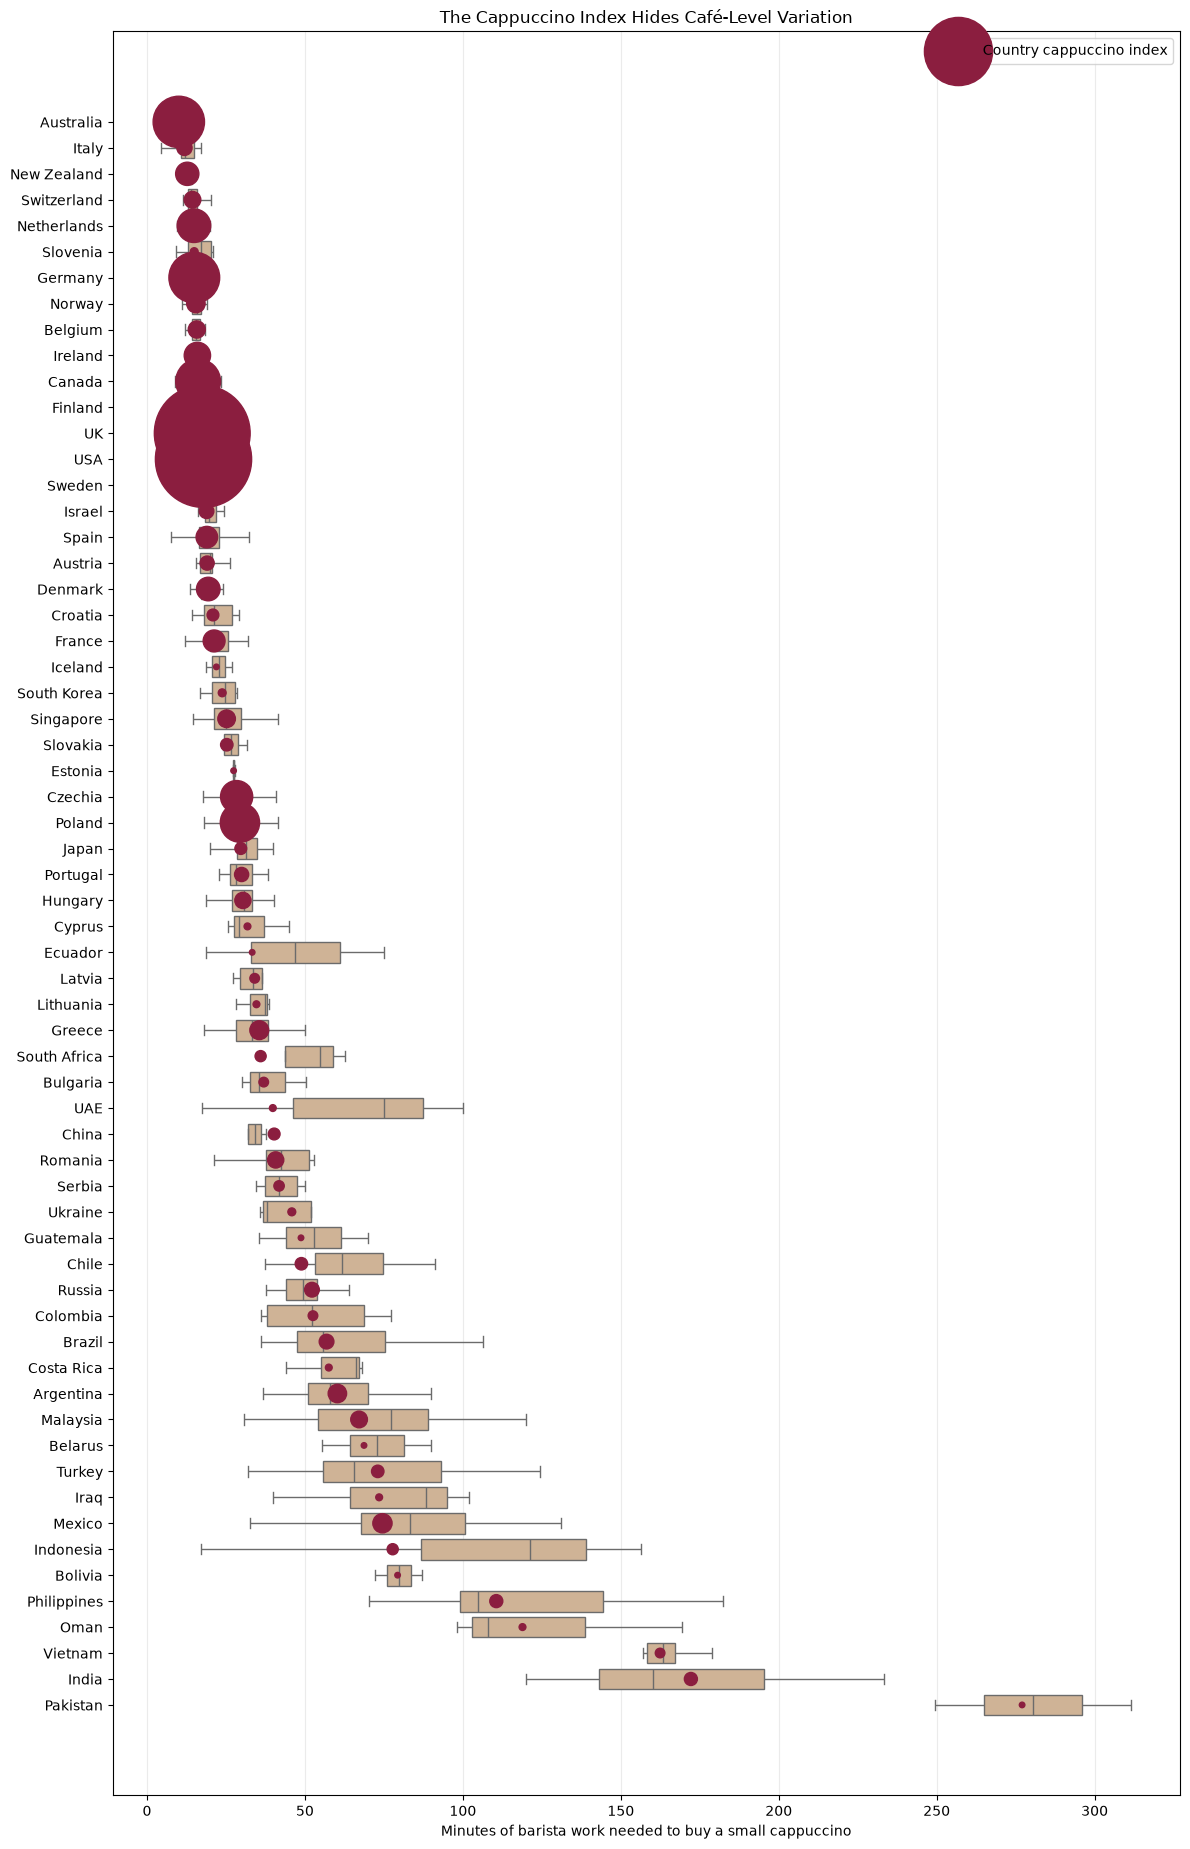

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-09-08/"

cafe = pd.read_csv(base_url + "cafe.csv")
index = pd.read_csv(base_url + "cappuccino_index.csv")

for df in (cafe, index):
    df["country"] = df["country"].str.replace("\u00a0", " ", regex=False)

cafe = cafe[
    (cafe["hourly_wage_gbp"] > 0) &
    (cafe["price_gbp"] > 0)
].copy()

cafe["minutes_to_buy"] = (
    cafe["price_gbp"] / cafe["hourly_wage_gbp"] * 60
)

# Keep countries with at least two cafés so variability is meaningful
counts = cafe.groupby("country").size()
countries = counts[counts >= 2].index

plot_data = cafe[cafe["country"].isin(countries)].copy()

# Order countries by the published cappuccino index
order = (
    index[index["country"].isin(countries)]
    .sort_values("index")["country"]
    .tolist()
)

plt.figure(figsize=(12, max(8, len(order) * 0.3)))

sns.boxplot(
    data=plot_data,
    y="country",
    x="minutes_to_buy",
    order=order,
    color="#d9b38c",
    showfliers=False
)

# Overlay the published country-level index
index_plot = index[index["country"].isin(order)].set_index("country").loc[order]

plt.scatter(
    index_plot["index"],
    range(len(index_plot)),
    color="#8b1e3f",
    s=index_plot["n"] * 8,
    zorder=3,
    label="Country cappuccino index"
)

plt.xlabel("Minutes of barista work needed to buy a small cappuccino")
plt.ylabel("")
plt.title("The Cappuccino Index Hides Café-Level Variation")
plt.legend()
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()